In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols



/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndat

## Load entropy results

In [70]:
# Load Cell Ranger  RNA filtering criteria barcodes
CR_rnamodality_BC_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/rna/VIB_10xmultiome_2_rna/outs/filtered_feature_bc_matrix/barcodes.tsv'
CR_rnamodality_bc = pd.read_csv(CR_rnamodality_BC_file, header=None, sep='\t', names=['barcodes'])

# Load Cell Ranger ATAC filtering criteria barcodes
CR_atacmodality_BC_file ='/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/filtered_peak_bc_matrix/barcodes.tsv'
CR_atacmodality_bc = pd.read_csv(CR_atacmodality_BC_file, header=None, sep='\t', names=['barcodes'])

CR_rnamodality_bc['rna_bc'] = CR_rnamodality_bc['barcodes'].map(lambda x: x.split('-1')[0])
CR_atacmodality_bc['atac_bc'] = CR_atacmodality_bc['barcodes'].map(lambda x: x.split('-1')[0])


# Load Entropy value for each barcode on atac 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
entropy_df_file = os.path.join(entropy_dir, 'chr1_barcode_entropy_df.tsv')
entropy_df = pd.read_csv(entropy_df_file, sep=',', index_col=0)
entropy_df['log10_Entropy'] = np.log10(entropy_df['Entropy'])
entropy_df['atac_bc'] = entropy_df.index.map(lambda x: x.split('-1')[0])


entropy_filtered_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_filtered_bc_df = pd.read_csv(entropy_filtered_bc_file, sep=',', index_col=0)
entropy_filtered_bc_df['atac_bc'] = entropy_filtered_bc_df.index.map(lambda x: x.split('-1')[0])

# Load Entropy filtered atac barcodes
# Use entropy_peak.obs or peak.obs # TODO: Change to be entropy_passed barcodes file 

# Load  atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')


def load_frag_overlap_peaks(frag_count_file):
    df = pd.read_csv(frag_count_file, sep=' ', index_col=1, header=None)
    df.columns = ['frag_overlap_peaks']
    df.index.name = None
    df['atac_bc'] = df.index.map(lambda x: x.split('-1')[0])
    df.reset_index(inplace=True, drop=False)
    df.set_index('atac_bc', inplace=True)
    return df

## Load Fragments overlap CR-called peaks counts 
CR_frag_overlap_CRpeaks_file = os.path.join(entropy_dir, '_CRpipe_peak_frag_overlap_peak', 'overlap_peaks_counts.txt')
CR_frag_overlap_CRpeaks = load_frag_overlap_peaks(CR_frag_overlap_CRpeaks_file)

cell_calling_method_subdir = os.path.join(entropy_dir, '_cell_palling_comparison_withTSSpeaks')

CR_1stRound_peaks_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'CR_1stRound_peaks', 'peaks_counts.txt')
CR_2ndRound_peaks_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'CR_2ndRound_peaks', 'peaks_counts.txt')
ArchR_TSS_peaks_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'ArchR_TSS_peaks', 'peaks_counts.txt')
entropy_filtered_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'peaks_entropy_filtered', 'peaks_counts.txt')

for f, n in zip([CR_1stRound_peaks_frag_overlap_file, CR_2ndRound_peaks_frag_overlap_file, ArchR_TSS_peaks_frag_overlap_file, entropy_filtered_frag_overlap_file], 
                 ['CR_1stRound_peaks', 'CR_2ndRound_peaks', 'ArchR_TSS_peaks', 'entropy_filtered_peaks']):
    df = load_frag_overlap_peaks(f)
    if n not in entropy_df.columns:
        entropy_df = entropy_df.merge(
            df[['frag_overlap_peaks']].rename(
                columns={'frag_overlap_peaks': f'frag_overlap_{n}'}),\
                                      left_on='atac_bc', right_index=True, how='left')
    


CR_2ndRound_unique_peak_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'CR_2ndRound_peaks_VS_CR_1stRound_peak', 'fragments_overlap_peaks/overlap_newly_discovered_peaks_counts.txt')
ArchR_unique_peak_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'ArchR_TSS_peak_VS_CR_1stRound_peak', 'fragments_overlap_peaks/overlap_newly_discovered_peaks_counts.txt')
Entropy_unique_peak_frag_overlap_file = os.path.join(cell_calling_method_subdir, 'peaks_entropy_filtered_peaks_VS_CR_1stRound_peak', 'fragments_overlap_peaks/overlap_newly_discovered_peaks_counts.txt')

for f, n in zip([CR_2ndRound_unique_peak_frag_overlap_file, ArchR_unique_peak_frag_overlap_file, Entropy_unique_peak_frag_overlap_file], 
                 ['CR_2ndRound_unique_peaks', 'ArchR_unique_peaks', 'Entropy_unique_peaks']):
    df = load_frag_overlap_peaks(f)
    if n not in entropy_df.columns:
        entropy_df = entropy_df.merge(
            df[['frag_overlap_peaks']].rename(
                columns={'frag_overlap_peaks': f'frag_overlap_{n}'}),\
                                      left_on='atac_bc', right_index=True, how='left')

In [17]:
# load AMULET doublet detection results
AMULET_doublet_file = os.path.join(entropy_dir, '_UnionBC_fragments/AMULET_output/MultipletProbabilities.txt')
AMULET_doublet_df = pd.read_csv(AMULET_doublet_file, sep='\t', index_col=0)
AMULET_doublet_df['atac_bc'] = AMULET_doublet_df.index.map(lambda x: x.split('-1')[0])
AMULET_doublet_df.reset_index(inplace=True, drop=False)
AMULET_doublet_df.set_index('atac_bc', inplace=True)
AMULET_doublet_df = AMULET_doublet_df.rename(columns={'p-value': 'AMULET_pvalue', 'q-value': 'AMULET_qvalue'}, inplace=False)

In [18]:
AMULET_doublet_df.head()

,cell_id,barcode,AMULET_pvalue,AMULET_qvalue
atac_bc,,,,
AAACAAGCAAGTTAGT,AAACAAGCAAGTTAGT-1,AAACAAGCAAGTTAGT-1,1.0,1.0
AAACAAGCATTTCTTC,AAACAAGCATTTCTTC-1,AAACAAGCATTTCTTC-1,1.0,1.0
AAACCGCCAACGGTAC,AAACCGCCAACGGTAC-1,AAACCGCCAACGGTAC-1,1.0,1.0
AAACCGCCAGAAACCC,AAACCGCCAGAAACCC-1,AAACCGCCAGAAACCC-1,1.0,1.0
AAACGAACACCTGTAT,AAACGAACACCTGTAT-1,AAACGAACACCTGTAT-1,1.0,1.0


### Load ArchR TSS cell-calling results

In [10]:
archr_cell_calling_file = os.path.join(entropy_dir, '_ArchR_TSS/archr_qc_df.csv')
archr_Tss_cell_call = pd.read_csv(archr_cell_calling_file)
archr_Tss_cell_call['atac_bc'] = archr_Tss_cell_call['cellNames'].apply(lambda x: x.split('#')[1].split('-')[0])
archr_Tss_cell_call = archr_Tss_cell_call.loc[archr_Tss_cell_call['Keep'] == 1 ]
archr_Tss_cell_call.shape

(2132, 13)

### Match RNA and ATAC abrcodes

In [19]:
bc_map = bc_map_pd.set_index('atac_barcodes')

if entropy_df.index.name != 'atac_barcodes':
    entropy_df.set_index('atac_bc', inplace=True)
    entropy_df.index.name = 'atac_barcodes'
    entropy_df['atac_bc'] = entropy_df.index.values
    
if 'rna_barcodes' not in entropy_df.columns:
    entropy_df = entropy_df.join(bc_map, how='inner')
    

entropy_df.shape

(33287, 13)

In [20]:
entropy_df['rna_pass_CR'] = entropy_df['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc'])
entropy_df['atac_pass_CR'] = entropy_df['atac_bc'].isin(CR_atacmodality_bc['atac_bc'])
entropy_df['atac_pass_entropy'] = entropy_df['atac_bc'].isin(entropy_filtered_bc_df['atac_bc'])
entropy_df['atac_pass_archr_TSS'] = entropy_df['atac_bc'].isin(archr_Tss_cell_call['atac_bc'])



In [21]:
entropy_df['2set_identified_by_atac_SC'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

entropy_df['identified_by_atac_SC_binary'] = entropy_df.apply(
    lambda row: 1 if row['2set_identified_by_atac_SC'] != 'none' else 0, axis=1
)

entropy_df['identified_by_atac_SC_binary'].sum(), entropy_df.groupby('2set_identified_by_atac_SC').size()





(2185,
 2set_identified_by_atac_SC
 both             1887
 cr_only            59
 entropy_only      239
 none            31102
 dtype: int64)

In [22]:
entropy_df['_2set_identified_by_atac_ST'] = entropy_df.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_archr_TSS'] else 
                 ('tss_only' if not row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 'none')), axis=1
)

entropy_df['identified_by_atac_ST_binary'] = entropy_df.apply(
    lambda row: 1 if row['_2set_identified_by_atac_ST'] != 'none' else 0, axis=1
)

entropy_df['identified_by_atac_ST_binary'].sum(), entropy_df.groupby('_2set_identified_by_atac_ST').size()



(2338,
 _2set_identified_by_atac_ST
 both             1910
 entropy_only      216
 none            30949
 tss_only          212
 dtype: int64)

In [23]:
entropy_df['identified_by_atac_binary'] =   entropy_df.apply(
    lambda row: 1 if row['2set_identified_by_atac_SC'] != 'none' or row['_2set_identified_by_atac_ST'] != 'none' else 0, axis=1
)

entropy_df['identified_by_atac_binary'].sum(),

(2365,)

## Load h5ads 

In [24]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac  -- TODO: delete 
# entropy_peak = sc.read_h5ad(entropy_peak_file)
# peak = sc.read_h5ad(peak_file)


In [25]:
h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1),
 (736320, 2))

In [26]:
bc_passed_entropy_df = entropy_df.loc[entropy_df['identified_by_atac_binary'] == 1].copy()

entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.shape

(2365, 22)

## Given that some BCs do not have valid entropy so they are not in entropy_df let's load all BCs from fragments file

In [27]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_BC'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']
frag.head()

,chrom,start,end,support,atac_bc,frag_length
atac_BC,,,,,,
AGTAGGCGTCCATTAA-1,chr1,10067,10198,1,AGTAGGCGTCCATTAA,131
TGAGGCATCATCAGTT-1,chr1,10085,10333,3,TGAGGCATCATCAGTT,248
CCTAACTCATTTCGCG-1,chr1,10090,10309,1,CCTAACTCATTTCGCG,219
CATCACTCAGGTATTG-1,chr1,10091,10327,1,CATCACTCAGGTATTG,236
ACTCCTAAGTCTTAGT-1,chr1,10097,10308,1,ACTCCTAAGTCTTAGT,211


In [76]:
_total_frag_per_bc = frag.groupby('atac_bc').size().to_frame()
_total_frag_per_bc.columns = ['total_fragments']
_total_frag_per_bc.head()

,total_fragments
atac_bc,
AAACAAGCAAACATGT,4
AAACAAGCAAACCAGC,1
AAACAAGCAAACCTAG,207
AAACAAGCAAACTAAC,1
AAACAAGCAAAGAAGC,987


In [77]:
_total_frag_per_bc['atac_pass_CR'] = _total_frag_per_bc.index.isin(CR_atacmodality_bc['atac_bc'])
_total_frag_per_bc['atac_pass_entropy'] = _total_frag_per_bc.index.isin(entropy_filtered_bc_df['atac_bc'])
_total_frag_per_bc['atac_pass_archr_TSS'] = _total_frag_per_bc.index.isin(archr_Tss_cell_call['atac_bc'])


if 'rna_barcodes' not in _total_frag_per_bc.columns:
    _total_frag_per_bc = _total_frag_per_bc.merge(bc_map, left_index=True, right_index=True, how='left')
    _total_frag_per_bc['rna_pass_CR'] = _total_frag_per_bc['rna_barcodes'].isin(CR_rnamodality_bc['rna_bc']) 

In [78]:
for f, n in zip([CR_1stRound_peaks_frag_overlap_file, CR_2ndRound_peaks_frag_overlap_file, ArchR_TSS_peaks_frag_overlap_file, entropy_filtered_frag_overlap_file], 
                 ['CR_1stRound_peaks', 'CR_2ndRound_peaks', 'ArchR_TSS_peaks', 'entropy_filtered_peaks']):
    df = load_frag_overlap_peaks(f)
    if n not in _total_frag_per_bc.columns:
        _total_frag_per_bc = _total_frag_per_bc.merge(
            df[['frag_overlap_peaks']].rename(
                columns={'frag_overlap_peaks': f'frag_overlap_{n}'}),\
                                      left_on='atac_bc', right_index=True, how='left')



for f, n in zip([CR_2ndRound_unique_peak_frag_overlap_file, ArchR_unique_peak_frag_overlap_file, Entropy_unique_peak_frag_overlap_file], 
                 ['CR_2ndRound_unique_peaks', 'ArchR_unique_peaks', 'Entropy_unique_peaks']):
    df = load_frag_overlap_peaks(f)
    if n not in _total_frag_per_bc.columns:
        _total_frag_per_bc = _total_frag_per_bc.merge(
            df[['frag_overlap_peaks']].rename(
                columns={'frag_overlap_peaks': f'frag_overlap_{n}'}),\
                                      left_on='atac_bc', right_index=True, how='left')

if 'Entropy' not in _total_frag_per_bc.columns:
    _total_frag_per_bc = _total_frag_per_bc.merge(entropy_df[['Entropy']], left_index=True, right_index=True, how='left') 

In [79]:
total_frag_per_bc = _total_frag_per_bc.loc[_total_frag_per_bc['atac_pass_CR'] | _total_frag_per_bc['atac_pass_entropy'] | _total_frag_per_bc['atac_pass_archr_TSS']].copy()
total_frag_per_bc

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,rna_barcodes,rna_pass_CR,frag_overlap_CR_1stRound_peaks,frag_overlap_CR_2ndRound_peaks,frag_overlap_ArchR_TSS_peaks,frag_overlap_entropy_filtered_peaks,frag_overlap_CR_2ndRound_unique_peaks,frag_overlap_ArchR_unique_peaks,frag_overlap_Entropy_unique_peaks,Entropy
atac_bc,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,GGCTAGTGTGTTAGCA,True,1707.0,1780.0,1924.0,1766.0,53.0,152.0,46.0,NaN
AAACAAGCATTTCTTC,9030,True,True,True,GGCTAGTGTACGTTTC,True,1496.0,1606.0,1854.0,1591.0,84.0,262.0,75.0,NaN
AAACCGCCAACGGTAC,1731,True,True,True,GATTCCTGTTAGCTGA,True,1253.0,1306.0,1409.0,1298.0,43.0,120.0,35.0,NaN
AAACCGCCAGAAACCC,786,True,True,False,GATTCCTGTGGTTCTT,True,395.0,409.0,441.0,407.0,8.0,36.0,7.0,NaN
AAACGAACACCTGTAT,1963,True,True,True,CTAGTGAGTCAATGTG,True,1136.0,1217.0,1410.0,1201.0,66.0,231.0,55.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGAGCATAAGTCG,14669,True,True,True,CTAACCTGTCCTTCAG,True,9317.0,9686.0,10570.0,9635.0,257.0,898.0,223.0,NaN
TTTGTCGAGCTAGTTT,5180,True,True,True,TTGCCCGTCGCATTAA,True,2589.0,2721.0,3082.0,2700.0,108.0,395.0,95.0,NaN
TTTGTGAGTCATCACG,5272,True,True,True,GGTAAACCAATGAATG,True,3935.0,4109.0,4481.0,4085.0,135.0,435.0,117.0,NaN


In [80]:
total_frag_per_bc['_2set_identified_by_atac_SC'] = total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_CR'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_CR'] else 
                 ('cr_only' if not row['atac_pass_entropy'] and row['atac_pass_CR'] else 'none')), axis=1
)

total_frag_per_bc['_2set_identified_by_atac_ST'] = total_frag_per_bc.apply(
    lambda row: 'both' if row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 
                ('entropy_only' if row['atac_pass_entropy'] and not row['atac_pass_archr_TSS'] else 
                 ('tss_only' if not row['atac_pass_entropy'] and row['atac_pass_archr_TSS'] else 'none')), axis=1
)



total_frag_per_bc['identified_by_atac_ST_binary'] = total_frag_per_bc.apply(
    lambda row: 1 if row['_2set_identified_by_atac_ST'] != 'none' else 0, axis=1
)

total_frag_per_bc['identified_by_atac_SC_binary'] = total_frag_per_bc.apply(
    lambda row: 1 if row['_2set_identified_by_atac_SC'] != 'none' else 0, axis=1
)

total_frag_per_bc['identified_by_atac_ST_binary'].sum(), total_frag_per_bc.groupby('_2set_identified_by_atac_ST').size()



(2348,
 _2set_identified_by_atac_ST
 both            1910
 entropy_only     216
 none              39
 tss_only         222
 dtype: int64)

In [81]:
total_frag_per_bc['identified_by_atac'] =total_frag_per_bc.apply(
    lambda x: 'all' if x['_2set_identified_by_atac_SC'] =='both' and x['_2set_identified_by_atac_ST'] =='both' else (
        'tss_only' if x['atac_pass_archr_TSS'] and not x['identified_by_atac_SC_binary'] else (
            'cr_only' if x['atac_pass_CR'] and not x['identified_by_atac_ST_binary'] else (
                'entropy_only' if x['_2set_identified_by_atac_SC'] == 'entropy_only' and  x['_2set_identified_by_atac_ST'] == 'entropy_only' else '2 out of 3'
            )
        )

    ), 
    axis=1
)

total_frag_per_bc.groupby('identified_by_atac').size()

identified_by_atac
2 out of 3       246
all             1792
cr_only           39
entropy_only     121
tss_only         189
dtype: int64

In [82]:
# Map atac-bc to rna-bc 
if 'rna_barcodes' not in total_frag_per_bc.columns:
    total_frag_per_bc = total_frag_per_bc.join(bc_map, how='inner')
    
total_frag_per_bc.index.name = 'atac_bc'
total_frag_per_bc.shape

(2387, 19)

# FRIP on each peak-set comparision among 3 cell-calling approaches

## On the whole peak-set

/tmp/ipykernel_2692186/3834165184.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'],
/tmp/ipykernel_2692186/3834165184.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'],
/tmp/ipykernel_2692186/3834165184.py:27: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'],


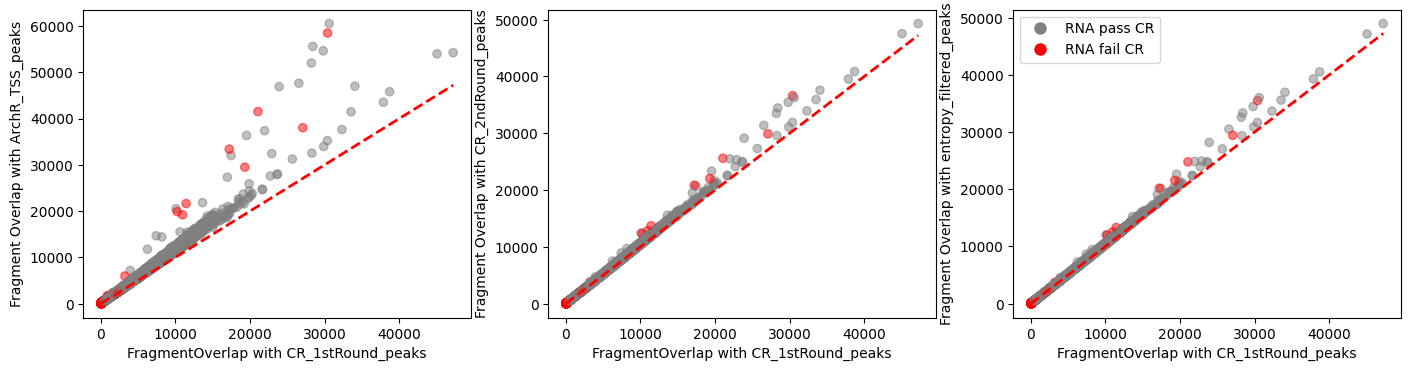

In [69]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'ArchR_TSS_peaks'
xlabel = 'CR_1stRound_peaks'
ax[0].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[0].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'frag_overlap_{xlabel}'].max()
ax[0].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'CR_2ndRound_peaks'
xlabel = 'CR_1stRound_peaks'
ax[1].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[1].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'frag_overlap_{xlabel}'].max()
ax[1].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)


ylabel = 'entropy_filtered_peaks'
xlabel = 'CR_1stRound_peaks'
ax[2].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'], 
           c =total_frag_per_bc['rna_pass_CR'].map({True: 'grey', False: 'red'}), cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FragmentOverlap with {xlabel}')
ax[2].set_ylabel(f'Fragment Overlap with {ylabel}')
vmax = total_frag_per_bc[f'frag_overlap_{xlabel}'].max()
ax[2].plot([0, vmax], [0, vmax],  color='red', linestyle='--', linewidth=2)

ax[2].legend(handles=[Line2D([0], [0], marker='o', color='w', label='RNA pass CR', markerfacecolor='grey', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='RNA fail CR', markerfacecolor='red', markersize=10)], loc='upper left')

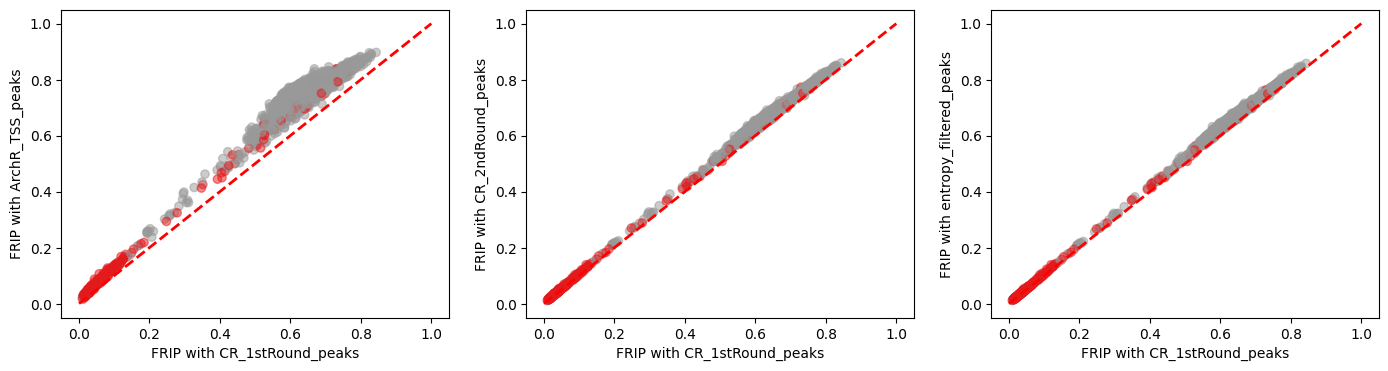

In [64]:
fig, ax = plt.subplots(ncols=3, figsize=(17, 4))

ylabel = 'ArchR_TSS_peaks'
xlabel = 'CR_1stRound_peaks'
ax[0].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'] / total_frag_per_bc['total_fragments'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'] / total_frag_per_bc['total_fragments'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[0].set_xlabel(f'FRIP with {xlabel}')
ax[0].set_ylabel(f'FRIP with {ylabel}')
ax[0].plot([0, 1], [0, 1],  color='red', linestyle='--', linewidth=2)


ylabel = 'CR_2ndRound_peaks'
xlabel = 'CR_1stRound_peaks'
ax[1].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'] / total_frag_per_bc['total_fragments'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'] / total_frag_per_bc['total_fragments'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[1].set_xlabel(f'FRIP with {xlabel}')
ax[1].set_ylabel(f'FRIP with {ylabel}')
ax[1].plot([0, 1], [0, 1],  color='red', linestyle='--', linewidth=2)


ylabel = 'entropy_filtered_peaks'
xlabel = 'CR_1stRound_peaks'
ax[2].scatter(total_frag_per_bc[f'frag_overlap_{xlabel}'] / total_frag_per_bc['total_fragments'], 
           total_frag_per_bc[f'frag_overlap_{ylabel}'] / total_frag_per_bc['total_fragments'], 
           c =total_frag_per_bc['rna_pass_CR'], cmap='Set1', alpha=0.5)
ax[2].set_xlabel(f'FRIP with {xlabel}')
ax[2].set_ylabel(f'FRIP with {ylabel}')
ax[2].plot([0, 1], [0, 1],  color='red', linestyle='--', linewidth=2)

In [244]:


# (total_frag_per_bc[f'frag_overlap_{ylabel}'] - total_frag_per_bc[f'frag_overlap_{xlabel}']).describe(), 
( (total_frag_per_bc[f'frag_overlap_{ylabel}'] - 
 total_frag_per_bc[f'frag_overlap_{xlabel}']) / total_frag_per_bc['total_fragments']
).describe()

count    2356.000000
mean       -0.571008
std         0.210946
min        -0.830303
25%        -0.698788
50%        -0.637503
75%        -0.563123
max        -0.007907
dtype: float64

## On cell-calling method unique peak subset

## Check low-quality BCs read-contributin for unique peaks 

In [86]:
total_frag_per_bc.groupby(['rna_pass_CR']).sum()

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,rna_barcodes,frag_overlap_CR_1stRound_peaks,frag_overlap_CR_2ndRound_peaks,frag_overlap_ArchR_TSS_peaks,frag_overlap_entropy_filtered_peaks,frag_overlap_CR_2ndRound_unique_peaks,frag_overlap_ArchR_unique_peaks,frag_overlap_Entropy_unique_peaks,Entropy,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,identified_by_atac_ST_binary,identified_by_atac_SC_binary,identified_by_atac
rna_pass_CR,,,,,,,,,,,,,,,,,,
False,8453351,68,138,236,TTAATCGAGCCTGGTAAGGACTAAGGCGCATCAATTGGGAGACAGG...,290228.0,324550.0,435930.0,318637.0,20496.0,97401.0,16877.0,0.0,nonenonenonenonenoneentropy_onlyentropy_onlyen...,tss_onlytss_onlytss_onlytss_onlytss_onlyentrop...,330,152,tss_onlytss_onlytss_onlytss_onlytss_onlyentrop...
True,37778144,1891,1988,1896,GGCTAGTGTGTTAGCAGGCTAGTGTACGTTTCGATTCCTGTTAGCT...,12055333.0,12702070.0,14313930.0,12599904.0,486541.0,1730880.0,409815.0,0.0,bothbothbothbothbothbothbothentropy_onlybothbo...,bothbothbothentropy_onlybothbothbothbothbothbo...,2018,2046,allallall2 out of 3allallall2 out of 3allallal...


In [ ]:
CR_2ndRound_unique_peak_file = os.path.join(cell_calling_method_subdir, 'CR_2ndRound_peaks_VS_CR_1stRound_peak', 'newly_discovered_peaks.bed')
ArchR_unique_peak_file = os.path.join(cell_calling_method_subdir, 'ArchR_TSS_peak_VS_CR_1stRound_peak', 'newly_discovered_peaks.bed')
Entropy_unique_peak_file = os.path.join(cell_calling_method_subdir, 'peaks_entropy_filtered_peaks_VS_CR_1stRound_peak', 'newly_discovered_peaks.bed')

def get_unique_peak_names(unique_peak_file):
    df = pd.read_csv(unique_peak_file, sep='\t', header=None)
    df = df[[0, 1, 2, 3]]
    df.columns = ['chrom', 'start', 'end', 'peak_id']
    return df

CR_2ndRound_unique_peaks = get_unique_peak_names(CR_2ndRound_unique_peak_file)
ArchR_unique_peaks = get_unique_peak_names(ArchR_unique_peak_file)
Entropy_unique_peaks = get_unique_peak_names(Entropy_unique_peak_file)

for df in [CR_2ndRound_unique_peaks, ArchR_unique_peaks, Entropy_unique_peaks]:
    df['peak_size'] = df['end'] - df['start']


CR_2ndRound_dropped_peak_file = os.path.join(cell_calling_method_subdir, 'CR_2ndRound_peaks_VS_CR_1stRound_peak', 'lost_peaks.bed')
ArchR_dropped_peak_file = os.path.join(cell_calling_method_subdir, 'ArchR_TSS_peak_VS_CR_1stRound_peak', 'lost_peaks.bed')
Entropy_dropped_peak_file = os.path.join(cell_calling_method_subdir, 'peaks_entropy_filtered_peaks_VS_CR_1stRound_peak', 'lost_peaks.bed')


CR_2ndRound_dropped_peaks = get_unique_peak_names(CR_2ndRound_dropped_peak_file)
ArchR_dropped_peaks = get_unique_peak_names(ArchR_dropped_peak_file)
Entropy_dropped_peaks = get_unique_peak_names(Entropy_dropped_peak_file)

In [255]:
CR_2ndRound_unique_peaks.head()

,chrom,start,end,peak_id,peak_size
0,chr1,976091,976507,peak_38,416
1,chr1,1079366,1080364,peak_49,998
2,chr1,1099013,1099865,peak_50,852
3,chr1,1216758,1217392,peak_60,634
4,chr1,1440975,1441155,peak_73,180


In [107]:
CR_1stRound_peaks_hit_file = os.path.join(cell_calling_method_subdir, 'CR_1stRound_peaks', 'peaks_frag_hit.bed')
CR_2ndRound_peaks_hit_file = os.path.join(cell_calling_method_subdir, 'CR_2ndRound_peaks', 'peaks_frag_hit.bed')
ArchR_TSS_peaks_hit_file = os.path.join(cell_calling_method_subdir, 'ArchR_TSS_peaks', 'peaks_frag_hit.bed')
entropy_filtered_peaks_hit_file = os.path.join(cell_calling_method_subdir, 'peaks_entropy_filtered', 'peaks_frag_hit.bed')


def get_peak_hit_df(peak_hit_file):
    df = pd.read_csv(peak_hit_file, sep='\t', header=None)
    df = df[[0, 1, 2, 3, 13]]
    df.columns = ['chrom', 'start', 'end', 'peak_id', 
                 'atac_bc_1' ]
    df['atac_bc'] = df['atac_bc_1'].map(lambda x: x.split('-1')[0])
    return df

df = get_peak_hit_df(CR_1stRound_peaks_hit_file)
df = df[ df['atac_bc'].isin(total_frag_per_bc.index) ]
CR_1stRound_peak_hits = df.groupby(['peak_id', 'atac_bc']).size().unstack(fill_value=0)

df = get_peak_hit_df(CR_2ndRound_peaks_hit_file)
df = df[ df['atac_bc'].isin(total_frag_per_bc.index) ]
CR_2ndRound_peaks_hits = df.groupby(['peak_id', 'atac_bc']).size().unstack(fill_value=0)

df = get_peak_hit_df(ArchR_TSS_peaks_hit_file)
df = df [df['atac_bc'].isin(total_frag_per_bc.index) ]
ArchR_TSS_peaks_hits = df.groupby(['peak_id', 'atac_bc']).size().unstack(fill_value=0)

df = get_peak_hit_df(entropy_filtered_peaks_hit_file)
df = df [df['atac_bc'].isin(total_frag_per_bc.index) ]
entropy_filtered_peaks_hits = df.groupby(['peak_id', 'atac_bc']).size().unstack(fill_value=0)

In [ ]:
from scipy.sparse import csc_matrix

def make_ad(peak_hits, unique_peaks):
    sparse_csc = csc_matrix(peak_hits.values)
    ad = sc.AnnData(X=sparse_csc,
                              var=peak_hits.columns.to_frame(index=False).set_index('atac_bc'),
                              obs=peak_hits.index.to_frame(index=False).set_index('peak_id')
                              )
    ad.obs['is_unique'] = ad.obs.index.isin(unique_peaks['peak_id'])  # Indicate method unique peaks
    return ad


entropy_peak_hits_ad = make_ad(entropy_filtered_peaks_hits, Entropy_unique_peaks)
CR_2ndRound_peak_hits_ad = make_ad(CR_2ndRound_peaks_hits, CR_2ndRound_unique_peaks)
ArchR_peak_hits_ad = make_ad(ArchR_TSS_peaks_hits, ArchR_unique_peaks)

entropy_peak_hits_ad.var = entropy_peak_hits_ad.var.join(total_frag_per_bc, how='left')
CR_2ndRound_peak_hits_ad.var = CR_2ndRound_peak_hits_ad.var.join(total_frag_per_bc, how='left')
ArchR_peak_hits_ad.var = ArchR_peak_hits_ad.var.join(total_frag_per_bc, how='left')


CR_1stRound_peak_hits_ad = sc.AnnData(X=csc_matrix(CR_1stRound_peak_hits.values),
                              var=CR_1stRound_peak_hits.columns.to_frame(index=False).set_index('atac_bc'),
                              obs=CR_1stRound_peak_hits.index.to_frame(index=False).set_index('peak_id')
                              )

CR_1stRound_peak_hits_ad.obs['CR_2ndRound_dropped'] = CR_1stRound_peak_hits_ad.obs.index.isin(CR_2ndRound_dropped_peaks['peak_id'])
CR_1stRound_peak_hits_ad.obs['ArchR_dropped'] = CR_1stRound_peak_hits_ad.obs.index.isin(ArchR_dropped_peaks['peak_id'])
CR_1stRound_peak_hits_ad.obs['Entropy_dropped'] = CR_1stRound_peak_hits_ad.obs.index.isin(Entropy_dropped_peaks['peak_id'])

CR_1stRound_peak_hits_ad.var = CR_1stRound_peak_hits_ad.var.join(total_frag_per_bc, how='left')


# normalize by bc-level read depth
for  ad_c in [ CR_1stRound_peak_hits_ad, CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad]:
        ad_c.layers['X_norm'] = ad_c.X.toarray() / ad_c.var['total_fragments'].values[None, :]


In [256]:
CR_1stRound_peak_hits_ad, CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad

(AnnData object with n_obs × n_vars = 30649 × 2387
     obs: 'CR_2ndRound_dropped', 'ArchR_dropped', 'Entropy_dropped'
     var: 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'rna_barcodes', 'rna_pass_CR', 'frag_overlap_CR_1stRound_peaks', 'frag_overlap_CR_2ndRound_peaks', 'frag_overlap_ArchR_TSS_peaks', 'frag_overlap_entropy_filtered_peaks', 'frag_overlap_CR_2ndRound_unique_peaks', 'frag_overlap_ArchR_unique_peaks', 'frag_overlap_Entropy_unique_peaks', 'Entropy', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'identified_by_atac_ST_binary', 'identified_by_atac_SC_binary', 'identified_by_atac'
     layers: 'X_norm',
 AnnData object with n_obs × n_vars = 37425 × 2387
     obs: 'is_unique'
     var: 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'rna_barcodes', 'rna_pass_CR', 'frag_overlap_CR_1stRound_peaks', 'frag_overlap_CR_2ndRound_peaks', 'frag_overlap_ArchR_TSS_peaks', 'frag_overlap_entropy_filtered_peak

Text(0.5, 0.98, 'each method dropped peaks hit counts in good vs bad RNA BCs')

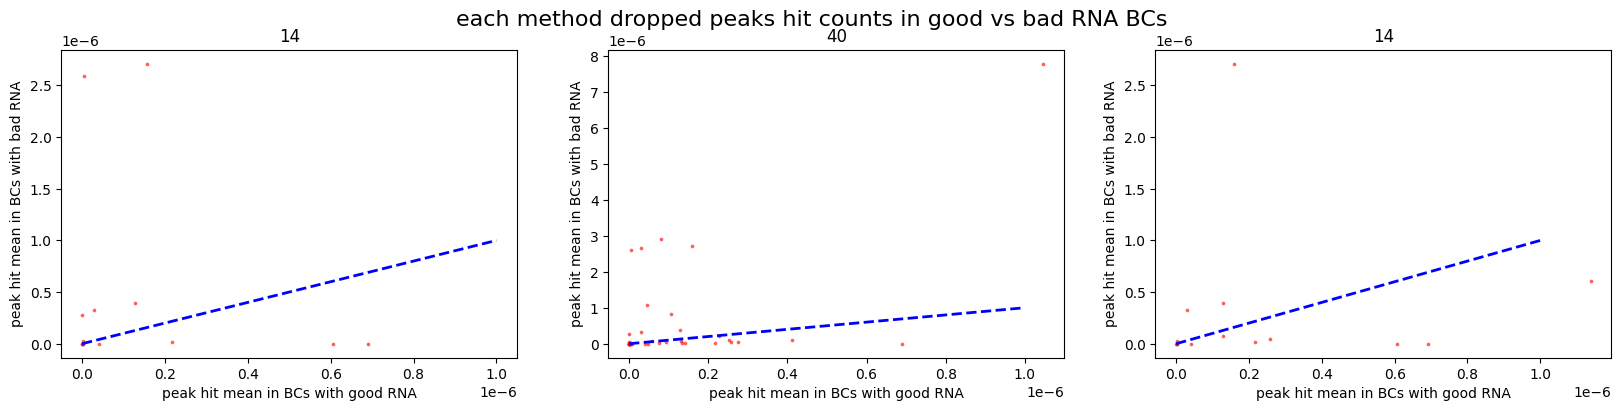

In [240]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 4))


for ax, drop in zip(axes, 
                    ['CR_2ndRound_dropped', 'ArchR_dropped', 'Entropy_dropped']
                    ):
    ad_c = CR_1stRound_peak_hits_ad[CR_1stRound_peak_hits_ad.obs[drop]]
    ax.scatter(
        ad_c[:, ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        ad_c[:, ~ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        color='red', 
        alpha=0.5, s=3
    )
    ax.set_xlabel('peak hit mean in BCs with good RNA')
    ax.set_ylabel('peak hit mean in BCs with bad RNA')
    ax.set_title(ad_c.shape[0])
    
    ax.plot([0, 0.1 * 1e-5], [0, 0.1 * 1e-5], color='blue', linestyle='--', linewidth=2)
fig.suptitle('each method dropped peaks hit counts in good vs bad RNA BCs', fontsize=16)


Text(0.5, 0.98, 'each method unique peaks hit counts in good vs bad RNA BCs')

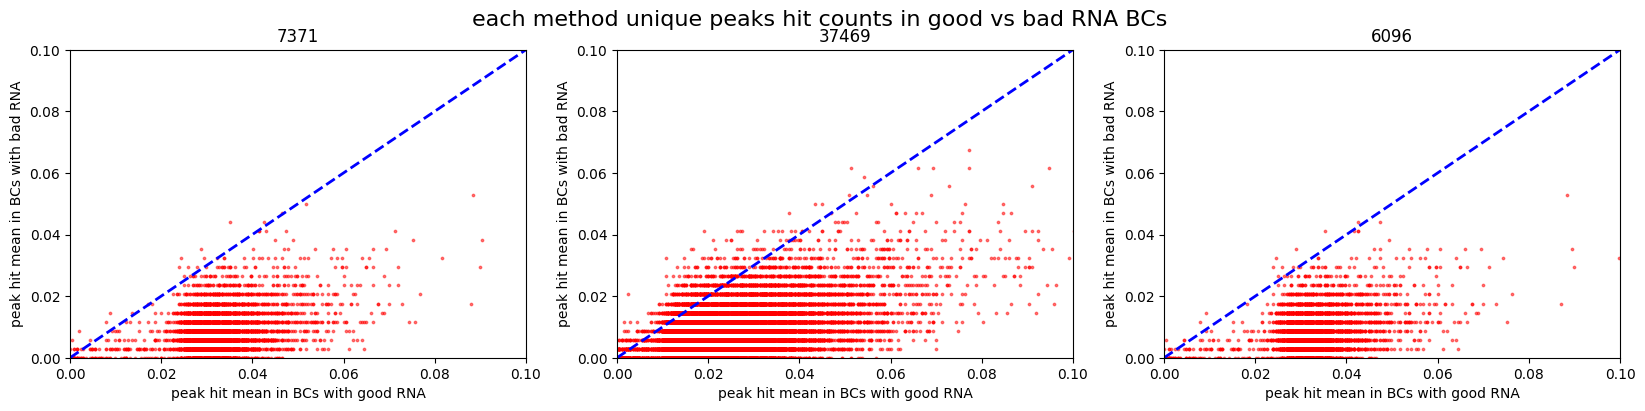

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 4))


for ax, ad_c in zip(axes, 
    [ CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad]
):
    ax.scatter(
        ad_c[ad_c.obs['is_unique'], ad_c.var['rna_pass_CR']].X.mean(axis=1).A1,
        ad_c[ad_c.obs['is_unique'], ~ad_c.var['rna_pass_CR']].X.mean(axis=1).A1,
        color='red', 
        alpha=0.5, s=3
    )
    ax.set_xlabel('peak hit mean in BCs with good RNA')
    ax.set_ylabel('peak hit mean in BCs with bad RNA')
    ax.set_title(ad_c.obs['is_unique'].sum())
    ax.set_ylim(0, 0.1)
    ax.set_xlim(0, 0.1)
    
    ax.plot([0, 0.1], [0, 0.1], color='blue', linestyle='--', linewidth=2)
fig.suptitle('each method unique peaks hit counts in good vs bad RNA BCs', fontsize=16)


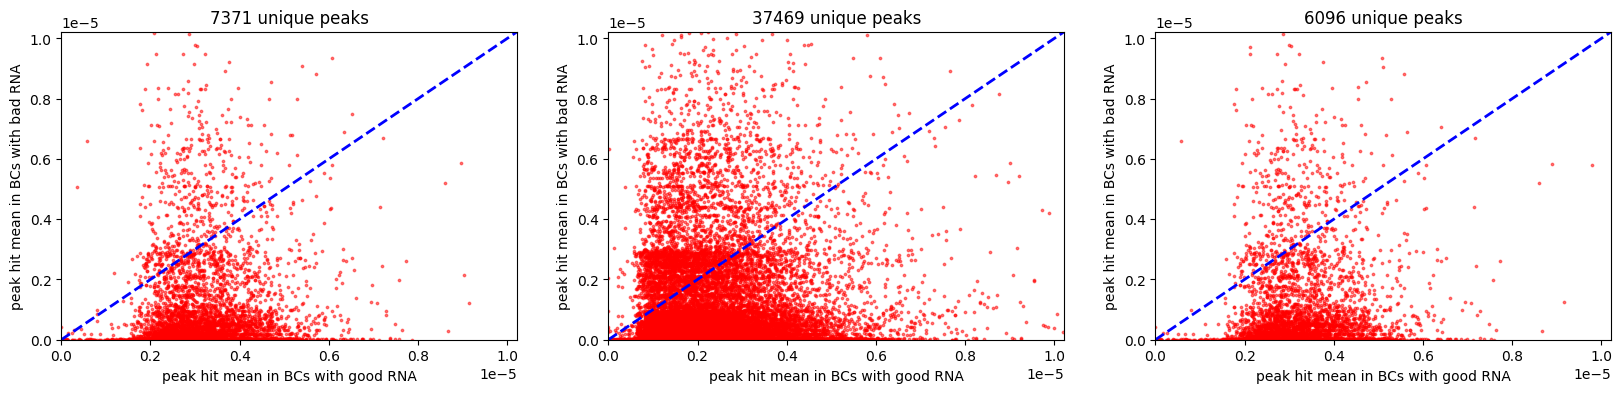

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 4))

vmax = ad_c.layers['X_norm'].max() * 0.001

for ax, ad_c in zip(axes, 
    [ CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad]
):
    ax.scatter(
        ad_c[ad_c.obs['is_unique'], ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        ad_c[ad_c.obs['is_unique'], ~ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        color='red', 
        alpha=0.5, s=3
    )
    ax.set_xlabel('peak hit mean in BCs with good RNA')
    ax.set_ylabel('peak hit mean in BCs with bad RNA')
    ax.set_title(f'{ad_c.obs["is_unique"].sum()} unique peaks')
    ax.set_ylim(0, vmax)
    ax.set_xlim(0, vmax)
    
    ax.plot([0, vmax], [0, vmax],  color='blue', linestyle='--', linewidth=2)
fig.suptitle('each method unique peaks hit counts in good vs bad RNA BCs', fontsize=16)


Text(0.5, 0.98, 'each method peak hit counts in good vs bad RNA BCs')

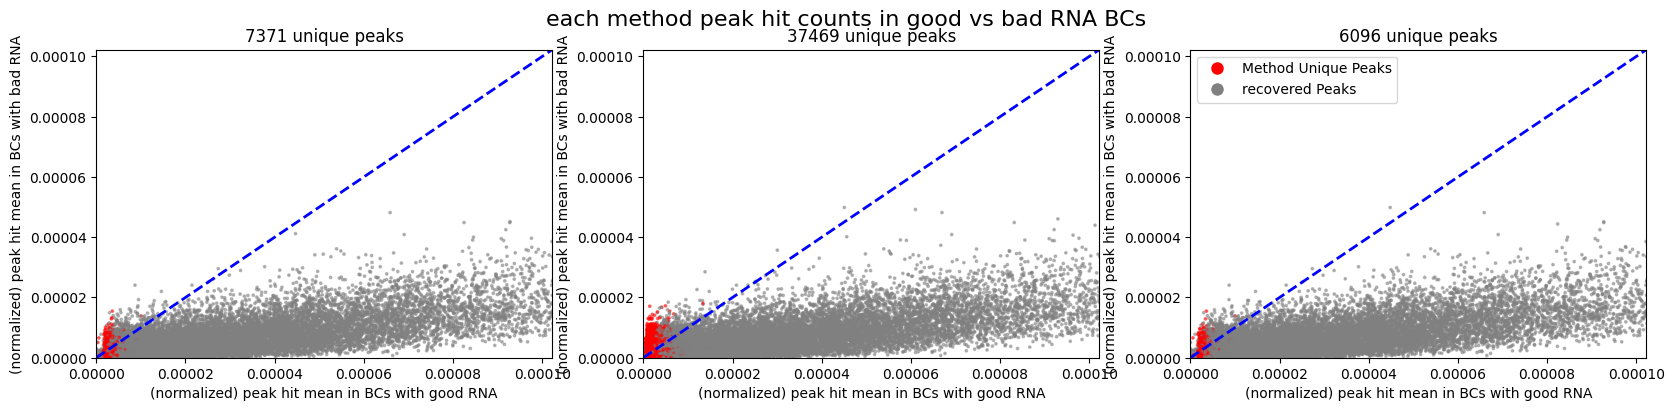

In [242]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 4))

vmax = ad_c.layers['X_norm'].max() * 0.001 * 10

for ax, ad_c in zip(axes, 
    [ CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad]
):
    ax.scatter(
        ad_c[:, ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        ad_c[:, ~ad_c.var['rna_pass_CR']].layers['X_norm'].mean(axis=1),
        c = ad_c.obs['is_unique'].map({True: 'red', False: 'grey'}),
        alpha=0.5, s=3
    )
    ax.plot([0, vmax], [0, vmax],  color='blue', linestyle='--', linewidth=2)
    
    ax.set_xlabel('(normalized) peak hit mean in BCs with good RNA')
    ax.set_ylabel('(normalized) peak hit mean in BCs with bad RNA')
    ax.set_title(f'{ad_c.obs["is_unique"].sum()} unique peaks')
    ax.set_ylim(0, vmax )
    ax.set_xlim(0, vmax )
    
    
axes[-1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Method Unique Peaks', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='recovered Peaks', markerfacecolor='grey', markersize=10)], loc='upper left')

fig.suptitle('each method peak hit counts in good vs bad RNA BCs', fontsize=16)


Text(0.5, 0.98, 'each method peaks hit counts in good vs bad RNA BCs')

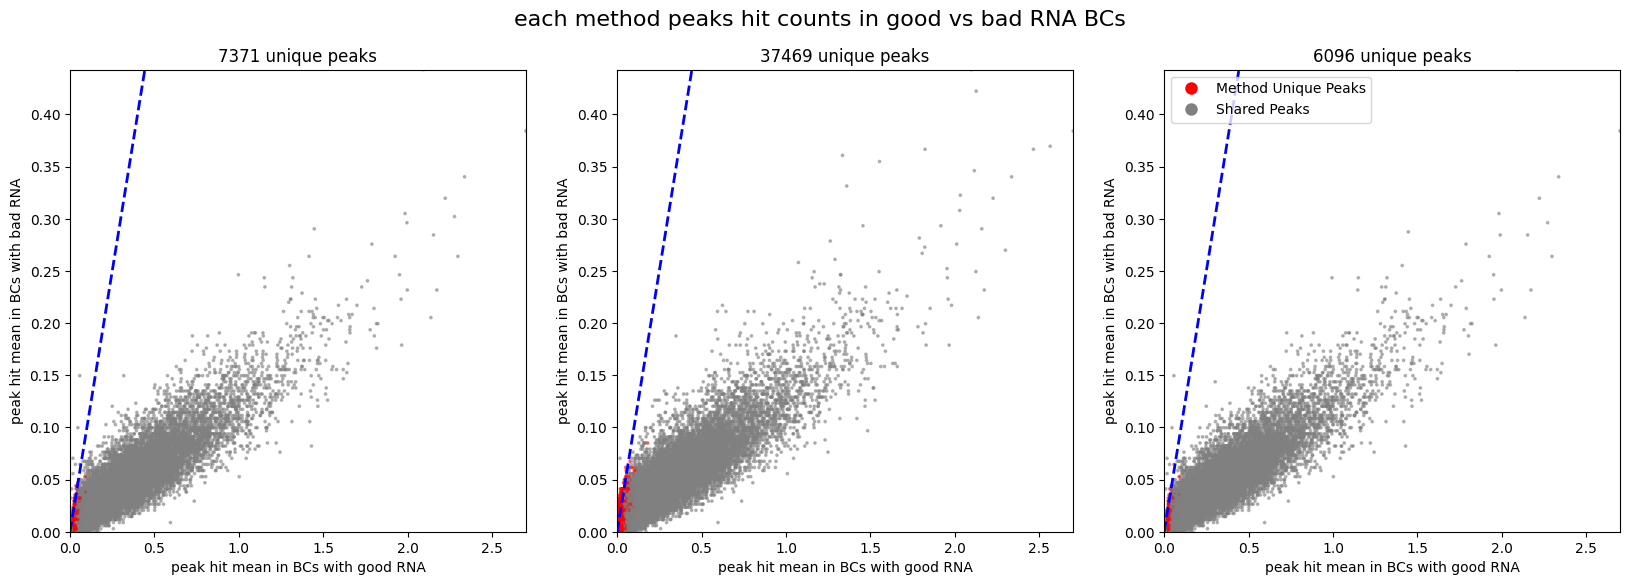

In [243]:
fig, axes = plt.subplots(ncols=3, figsize=(20, 6))

vmax = ad_c[:, ad_c.var['rna_pass_CR']].X.mean(axis=1).max()
ymax = ad_c[:, ~ad_c.var['rna_pass_CR']].X.mean(axis=1).max()

for ax, ad_c in zip(axes, 
    [ CR_2ndRound_peak_hits_ad, ArchR_peak_hits_ad, entropy_peak_hits_ad]
):
    ax.scatter(
        ad_c[:, ad_c.var['rna_pass_CR']].X.mean(axis=1).A1,
        ad_c[:, ~ad_c.var['rna_pass_CR']].X.mean(axis=1).A1,
        c = ad_c.obs['is_unique'].map({True: 'red', False: 'grey'}),
        alpha=0.5, s=3
    )
    
    ax.set_xlabel('peak hit mean in BCs with good RNA')
    ax.set_ylabel('peak hit mean in BCs with bad RNA')
    ax.set_xlim(0, vmax)
    ax.set_ylim(0, ymax)
    ax.set_title(f'{ad_c.obs["is_unique"].sum()} unique peaks')
    
    ax.plot([0, max(vmax, ymax)], [0, max(vmax, ymax)],  color='blue', linestyle='--', linewidth=2)
    
axes[-1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Method Unique Peaks', markerfacecolor='red', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Shared Peaks', markerfacecolor='grey', markersize=10)], loc='upper left') 

fig.suptitle('each method peaks hit counts in good vs bad RNA BCs', fontsize=16)


# Peak sizes

In [260]:
CR_2ndRound_unique_peaks['peak_size']

0       416
1       998
2       852
3       634
4       180
       ... 
7415    312
7416    366
7417    354
7418    420
7419    208
Name: peak_size, Length: 7420, dtype: int64

----- 	 CR_2ndRound 	 ArchR 	 entropy_only
mean 	 [328.5832884097035, 406.1056785676449, 323.3182928815768]
median 	 [288.0, 355.0, 284.0]


Text(0.5, 0.98, 'size distribution of method Unique peaks')

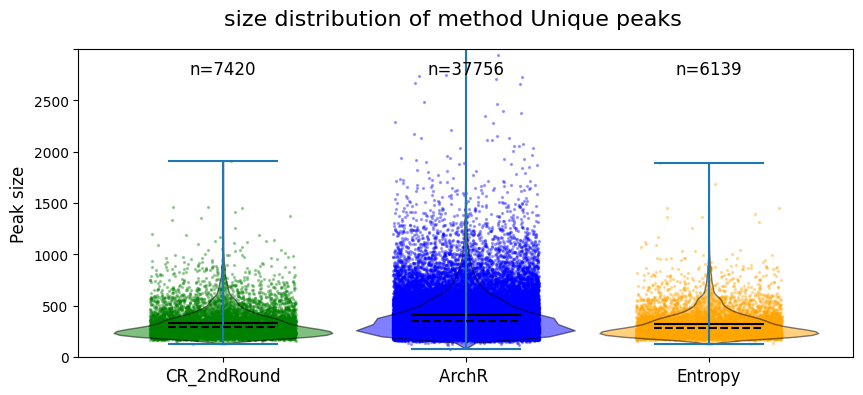

In [272]:
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))

x_positions = range(3)
width = 0.9

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ CR_2ndRound_unique_peaks['peak_size'], ArchR_unique_peaks['peak_size'], Entropy_unique_peaks['peak_size'] ]
total_counts = [ CR_2ndRound_unique_peaks.shape[0], ArchR_unique_peaks.shape[0], Entropy_unique_peaks.shape[0] ]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['CR_2ndRound',  'ArchR ', 'Entropy'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Peak size', fontsize=12)
ax.set_ylim(0, 3000)
# ax.set_yticks(range(0, 51, 10))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

print('----- \t CR_2ndRound \t ArchR \t entropy_only')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

fig.suptitle('size distribution of method Unique peaks', fontsize=16)

# RNA clustering

In [116]:
bc_pass_atac_df = total_frag_per_bc.copy()
bc_pass_atac_df_map = bc_pass_atac_df.reset_index(inplace=False).set_index('rna_barcodes')


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(bc_pass_atac_df_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(bc_pass_atac_df_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [45]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2387 × 36588
     obs: 'barcodes', 'atac_bc', 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'CRpeak_FRIP', 'total_fragment_log1p', 'rna_pass_CR', 'frag_overlap_CRpeaks', 'Entropy', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'identified_by_atac_ST_binary', 'identified_by_atac_SC_binary', 'identified_by_atac', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2387, 36601))

In [46]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [47]:
SCVI_LATENT_KEY = "RNA_scVI"
SCVI_CLUSTERS_KEY = "leiden_RNA_scVI"

scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

h5_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(entropy_dir, "_unioncells_RNA_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "RNA_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
# h5_rna.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# sc.pp.neighbors(h5_rna, use_rep=SCVI_LATENT_KEY)
# sc.tl.umap(h5_rna, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(h5_rna, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(h5_rna, min_dist=0.3)
sc.tl.leiden(h5_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/gener

Epoch 400/400: 100%|██████████| 400/400 [01:37<00:00,  4.12it/s, v_num=1, train_loss_step=4.91e+3, train_loss_epoch=4.75e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:37<00:00,  4.10it/s, v_num=1, train_loss_step=4.91e+3, train_loss_epoch=4.75e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



/tmp/ipykernel_2538860/3817777607.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(h5_rna, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)


### Vis on RNA spcae

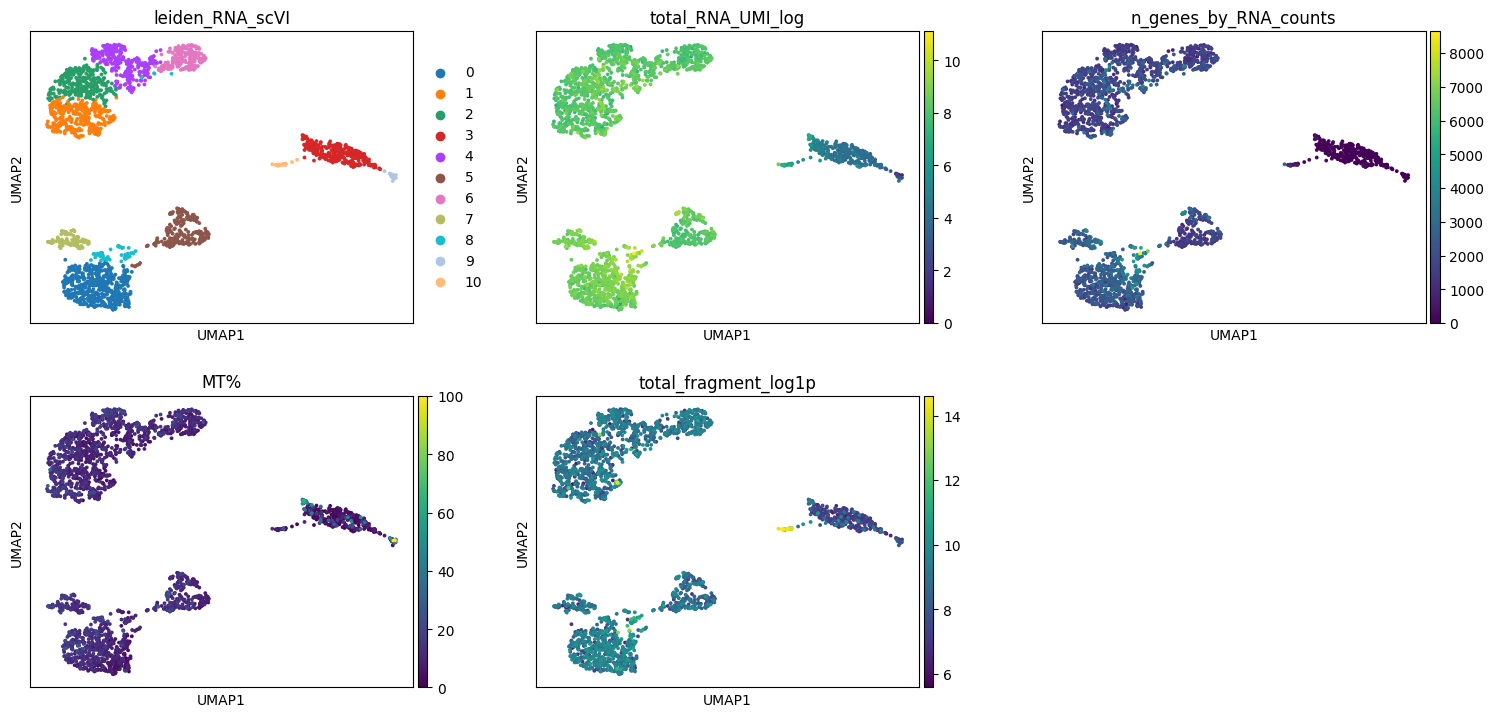

In [48]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%', 'total_fragment_log1p'], wspace=0.2, size=30, ncols=3)

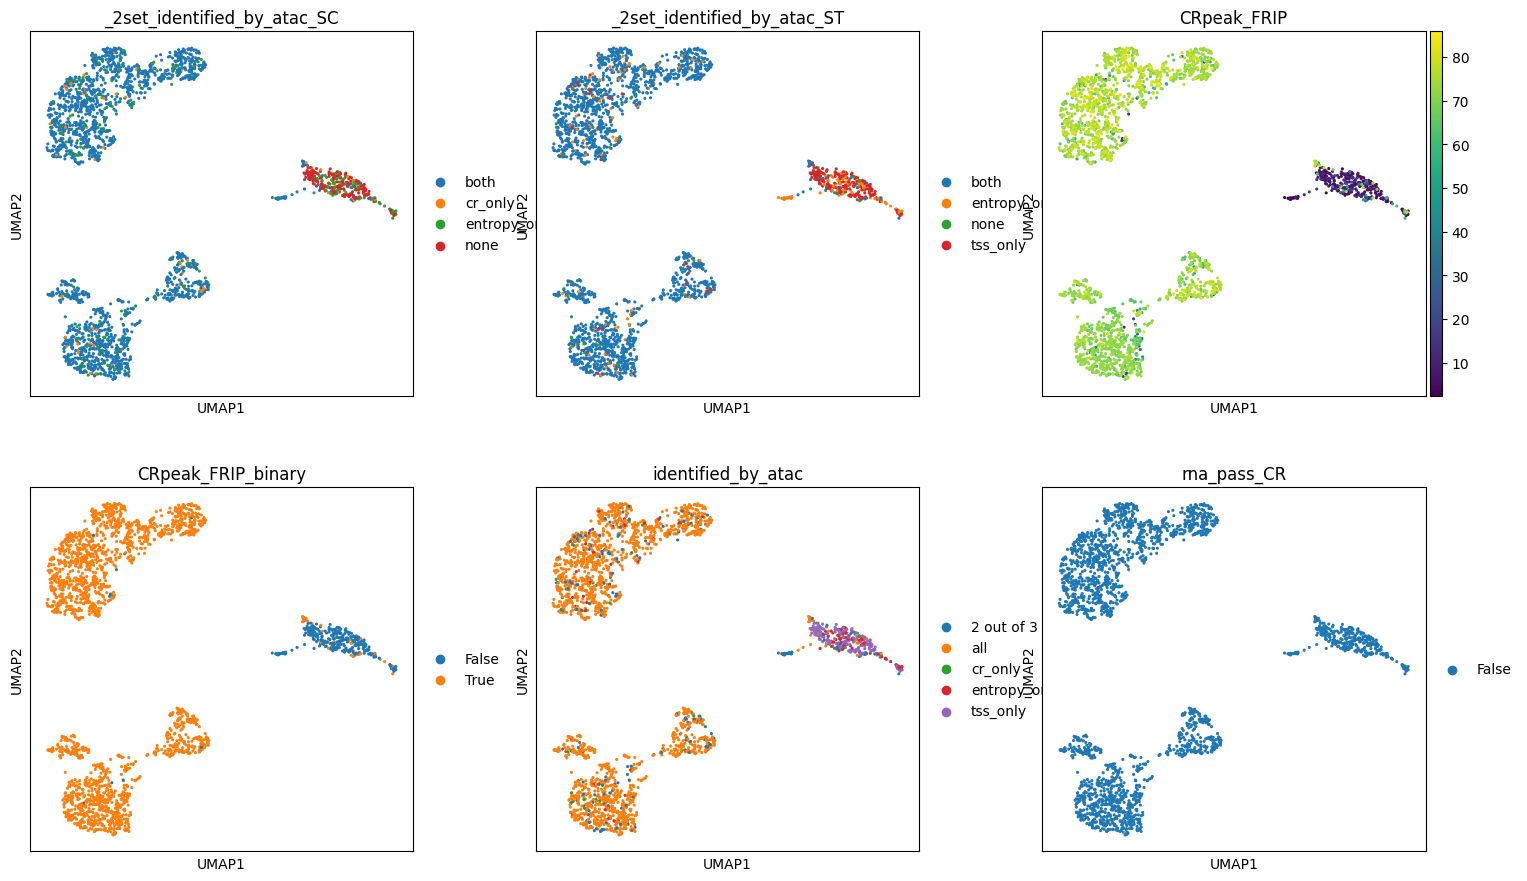

In [49]:
h5_rna.obs['CRpeak_FRIP_binary'] = h5_rna.obs['CRpeak_FRIP'] > 20

with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['_2set_identified_by_atac_SC',
                              '_2set_identified_by_atac_ST', 
                              'CRpeak_FRIP' , 'CRpeak_FRIP_binary', 
                              'identified_by_atac',
                              'rna_pass_CR'], wspace=0.2, size=20, ncols=3)

<Axes: xlabel='leiden_RNA_scVI', ylabel='count'>

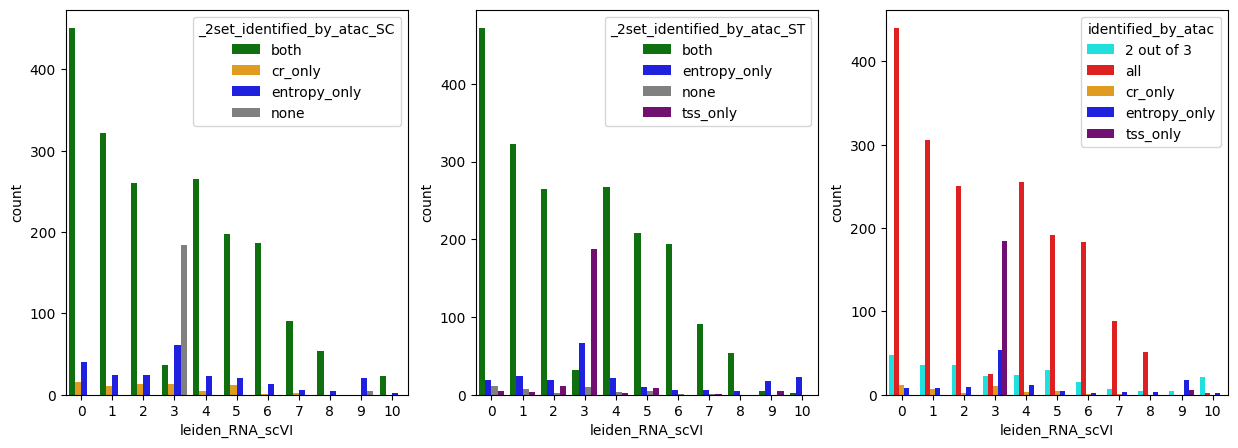

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
color_dic = {'both': 'green', 'entropy_only': 'blue', 'cr_only': 'orange',   'tss_only': 'purple', 'none': 'grey', '2 out of 3': 'cyan', 'all': 'red'}
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_SC', palette=color_dic, ax=ax[0])
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='_2set_identified_by_atac_ST', palette=color_dic, ax=ax[1])
sns.countplot(data=h5_rna.obs, x='leiden_RNA_scVI', hue='identified_by_atac', palette=color_dic, ax=ax[2])

#### show barcodes 

In [70]:

h5_rna.obs.to_csv(os.path.join(entropy_dir, '_cell_palling_comparison',  'Union_3set_atac_BCs.tsv'), sep='\t', index=True)

In [71]:
h5_rna.obs.groupby(['identified_by_atac']).size()

/tmp/ipykernel_2386509/2240697696.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['identified_by_atac']).size()


identified_by_atac
2 out of 3       246
all             1792
cr_only           39
entropy_only     121
tss_only         189
dtype: int64

## Check Doublet schore 

In [25]:
if 'AMULET_qvalue' not in h5_rna.obs.columns :
    h5_rna.obs = h5_rna.obs.merge(AMULET_doublet_df[['AMULET_pvalue', 'AMULET_qvalue']], left_on='atac_bc', right_index=True, how='left')
    h5_rna.obs['AMULET_doublet'] = h5_rna.obs['AMULET_qvalue'] < 0.05

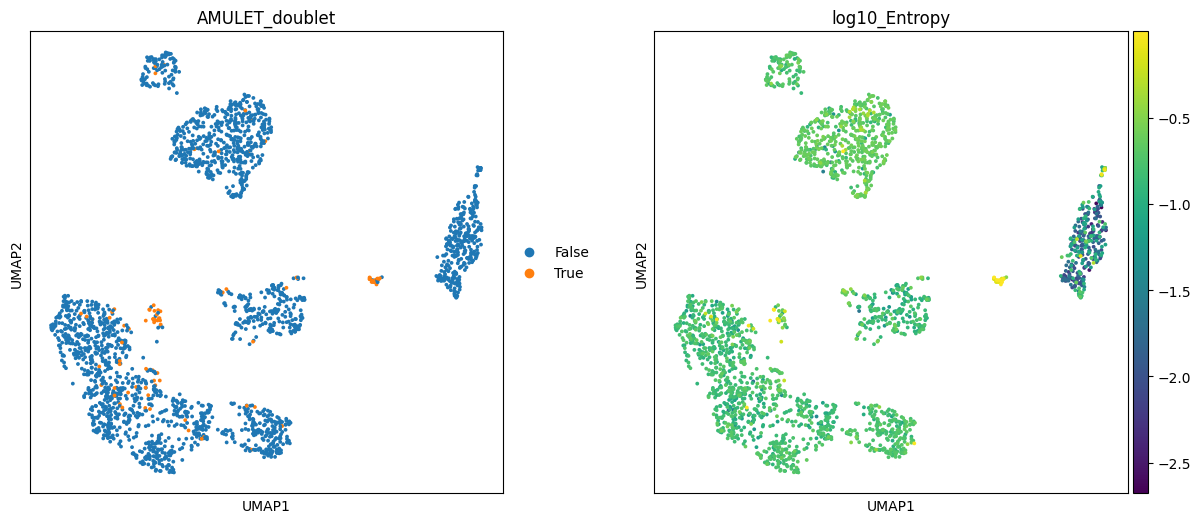

In [26]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(h5_rna, color=['AMULET_doublet', 'log10_Entropy'], wspace=0.2, size=30, ncols=2)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


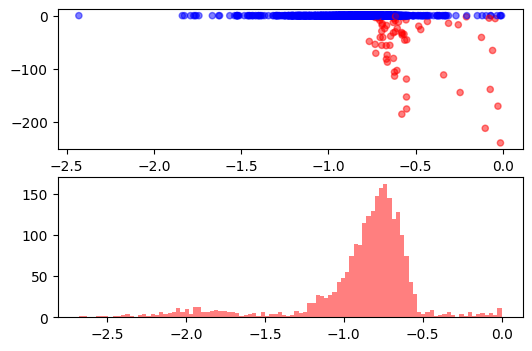

In [27]:
fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(6, 4))
ax[0].scatter( h5_rna.obs['log10_Entropy'], np.log10(h5_rna.obs['AMULET_qvalue']), c=h5_rna.obs['AMULET_doublet'].map({True: 'red', False: 'blue'}), alpha=0.5, s=20)

_ = ax[1].hist(h5_rna.obs['log10_Entropy'], bins=100, alpha=0.5, label='Doublets', color='red')

In [ ]:
h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()

/tmp/ipykernel_223282/3685671454.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['AMULET_doublet', 'identified_by_atac']).size().unstack()


identified_by_atac,both,cr_only,entropy_only
AMULET_doublet,,,
False,1796,59,238
True,91,0,1


## ATAC clsutering

In [ ]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
bc_passed_entropy_df = entropy_df.loc[entropy_df['identified_by_atac_binary'] == 1].copy()

entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)


h5_atac_ = h5.transpose()
h5_atac_.obs['rna_barcodes'] = h5_atac_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_atac_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_atac_ = h5_atac_[:, h5_atac_.var['feature_type'] == 'Peaks']
h5_atac_ = h5_atac_[h5_atac_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_atac_.obs = h5_atac_.obs.join(entropy_passed_bc_map, how='inner')


# Add gene_name column 
h5_atac_.var['peak_name'] = h5_atac_.var.apply(lambda x: x['chrom'] + ':' + str(x['start']) + '-' + str(x['end']), axis=1)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [80]:
h5_atac_

AnnData object with n_obs × n_vars = 2185 × 67467
    obs: 'barcodes', 'atac_barcodes', 'Entropy', 'Entropy_open_region', 'Mp', 'mle_lambda', 'P0_open_region', 'P_closed_state', 'log10_Entropy', 'standard_peak_FRIP', 'total_fragments', 'Nfrag_overlap_standard_peak', 'entropy_peak_FRIP', 'Nfrag_overlap_entropy_peak', 'frag_overlap_CRpeaks', 'total_fragment_log1p', 'CRpeak_FRIP', 'atac_bc', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'identified_by_atac', 'identified_by_atac_binary'
    var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'peak_name'

In [81]:
PEAKVI_LATENT_KEY = "X_peakvi"
PEAKVI_CLUSTERS_KEY = "leiden_atac"

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)
#%%
# filter regions with less than 3% of the cells
# print("# regions before filtering:", h5_atac_.shape[-1])
# sc.pp.filter_genes(h5_atac_, min_cells=10)

# train on atac_adata
scvi.model.PEAKVI.setup_anndata(h5_atac_)
peak_model = scvi.model.PEAKVI(h5_atac_)
peak_model.train()

# save latent representation back adata
latent = peak_model.get_latent_representation()
h5_atac_.obsm[PEAKVI_LATENT_KEY] = latent


# save model
print("Save integrated samples into .h5ad file and trained PEAKVI model into subfolder\n") 
des_model_dir = os.path.join(entropy_dir, "_unioncells_peakvi_model")
peak_model.save(des_model_dir, overwrite=True)


latent.shape
# save clustering results back to atac_adata
sc.pp.neighbors(h5_atac_, use_rep=PEAKVI_LATENT_KEY)
sc.tl.umap(h5_atac_, min_dist=0.2)
sc.tl.leiden(h5_atac_, key_added=PEAKVI_CLUSTERS_KEY, resolution=atac_resolution)



Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Last run with scvi-tools version: 1.2.0


/tmp/ipykernel_2726626/1595958498.py:14: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  peak_model.train()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers

Epoch 81/500:  16%|█▌        | 81/500 [01:14<06:24,  1.09it/s, v_num=1, train_loss_step=2.72e+7, train_loss_epoch=1.84e+8]
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 13825.001. Signaling Trainer to stop.
Save integrated samples into .h5ad file and trained PEAKVI model into subfolder



### Vis on atac space

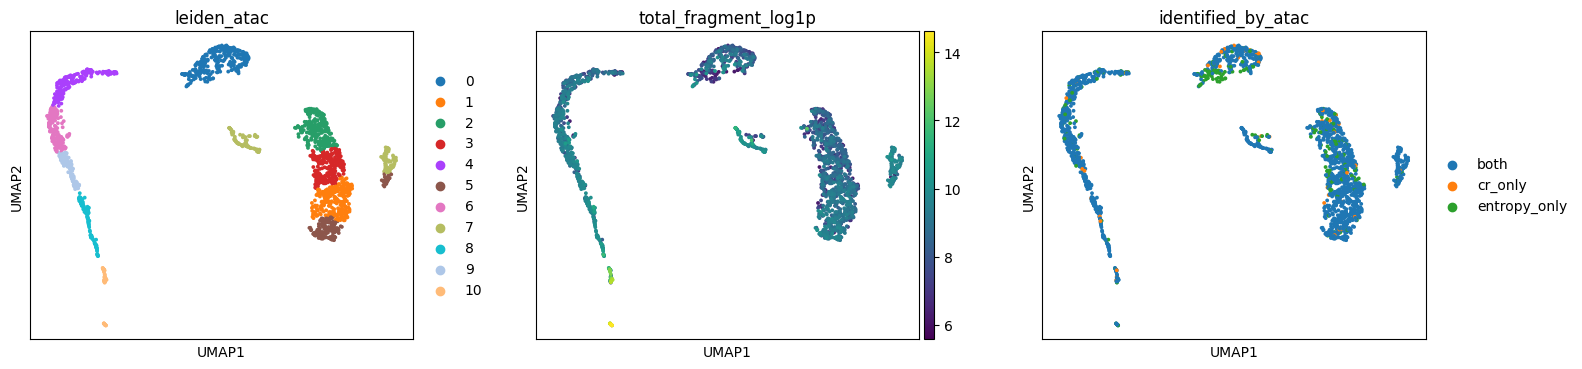

In [82]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_atac_, color=['leiden_atac', 'total_fragment_log1p', 'identified_by_atac'], wspace=0.2, size=30, ncols=3)

# ATAC space with peak-set with the most number of peaks

In [84]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
TSS_peak_h5_dir = os.path.join(entropy_dir, '_cell_palling_comparison_withTSSpeaks/DownstreamReanalysis')
TSS_peak_h5_file = os.path.join(TSS_peak_h5_dir, 'bc_peak_count.h5ad')


h5_atac_TSSpeak = sc.read_h5ad(TSS_peak_h5_file)
h5_atac_ = h5_atac_TSSpeak.copy()
h5_atac_.obs['atac_bc'] = h5_atac_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_atac_.obs.set_index('atac_bc', inplace=True)


# Add gene_name column 
h5_atac_.var['peak_name'] = h5_atac_.var['peak']


gene_activity_h5_file = os.path.join(TSS_peak_h5_dir, 'gene_activity_score_by_bc.csv')
gene_activity_h5_df = pd.read_csv(gene_activity_h5_file, index_col=0)
gene_activity_h5 = sc.AnnData(X=gene_activity_h5_df.values.T, 
                              var=gene_activity_h5_df.index.to_frame(), obs=pd.DataFrame(index=gene_activity_h5_df.columns))
gene_activity_h5.obs['atac_bc'] = gene_activity_h5.obs.index.map(lambda x: x.split('.1')[0])
gene_activity_h5.obs = gene_activity_h5.obs.reset_index(inplace=False, drop=True)
gene_activity_h5.obs = gene_activity_h5.obs.set_index('atac_bc', inplace=False)
gene_activity_h5.obs = gene_activity_h5.obs.merge(total_frag_per_bc, left_on='atac_bc', right_index=True, how='left')

In [85]:
gene_activity_h5

AnnData object with n_obs × n_vars = 2386 × 19615
    obs: 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'CRpeak_FRIP', 'total_fragment_log1p', 'rna_pass_CR', 'frag_overlap_CRpeaks', 'Entropy', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'identified_by_atac_ST_binary', 'identified_by_atac_SC_binary', 'identified_by_atac', 'rna_barcodes'
    var: 0

In [86]:
sc.pp.filter_genes(gene_activity_h5, min_counts=3)
gene_activity_h5.raw = gene_activity_h5 # keep full dimension safe
gene_activity_h5.layers['counts'] = gene_activity_h5.X
sc.pp.highly_variable_genes(
gene_activity_h5,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [87]:
gene_activity_h5

AnnData object with n_obs × n_vars = 2386 × 19361
    obs: 'total_fragments', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', 'CRpeak_FRIP', 'total_fragment_log1p', 'rna_pass_CR', 'frag_overlap_CRpeaks', 'Entropy', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', 'identified_by_atac_ST_binary', 'identified_by_atac_SC_binary', 'identified_by_atac', 'rna_barcodes'
    var: 0, 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'
    layers: 'counts'

In [88]:
SCVI_LATENT_KEY = "Geneactivity_scVI"
SCVI_CLUSTERS_KEY = "leiden_Geneactivity_scVI"

scvi.settings.seed = 0
scvi.model.SCVI.setup_anndata(gene_activity_h5, layer="counts")
vae = scvi.model.SCVI(gene_activity_h5, n_layers=3, n_latent=30, gene_likelihood="nb")
vae.train()

gene_activity_h5.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()

print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
vae_model_folder=os.path.join(TSS_peak_h5_dir, "_unioncells_geneactivity_scvi_model")
vae.save(vae_model_folder, overwrite=True)
# vae_model_folder=os.path.join(entropy_dir, "_unioncells_geneactivity_scvi_model")
# vae =scvi.model.SCVI.load(vae_model_folder, adata=gene_activity_h5)
# gene_activity_h5.obsm[SCVI_LATENT_KEY] = vae.get_latent_representation()
# sc.pp.neighbors(gene_activity_h5, use_rep=SCVI_LATENT_KEY)
# sc.tl.umap(gene_activity_h5, min_dist=0.3)


# clustering using scVI latent representation via Leiden
atac_resolution = 0.5
sc.pp.neighbors(gene_activity_h5, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(gene_activity_h5, min_dist=0.3)
sc.tl.leiden(gene_activity_h5, key_added=SCVI_CLUSTERS_KEY, resolution=atac_resolution + 0.1)

Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 400/400: 100%|██████████| 400/400 [01:03<00:00,  6.29it/s, v_num=1, train_loss_step=1.07e+4, train_loss_epoch=1.08e+4]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:03<00:00,  6.33it/s, v_num=1, train_loss_step=1.07e+4, train_loss_epoch=1.08e+4]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



### Vis on gene-activity score space 

In [90]:
if 'leiden_RNA_scVI' not in gene_activity_h5.obs.columns:
    gene_activity_h5.obs = gene_activity_h5.obs.merge(h5_rna.obs[['leiden_RNA_scVI', 'atac_bc']], left_on='rna_barcodes', right_index=True, how='left')

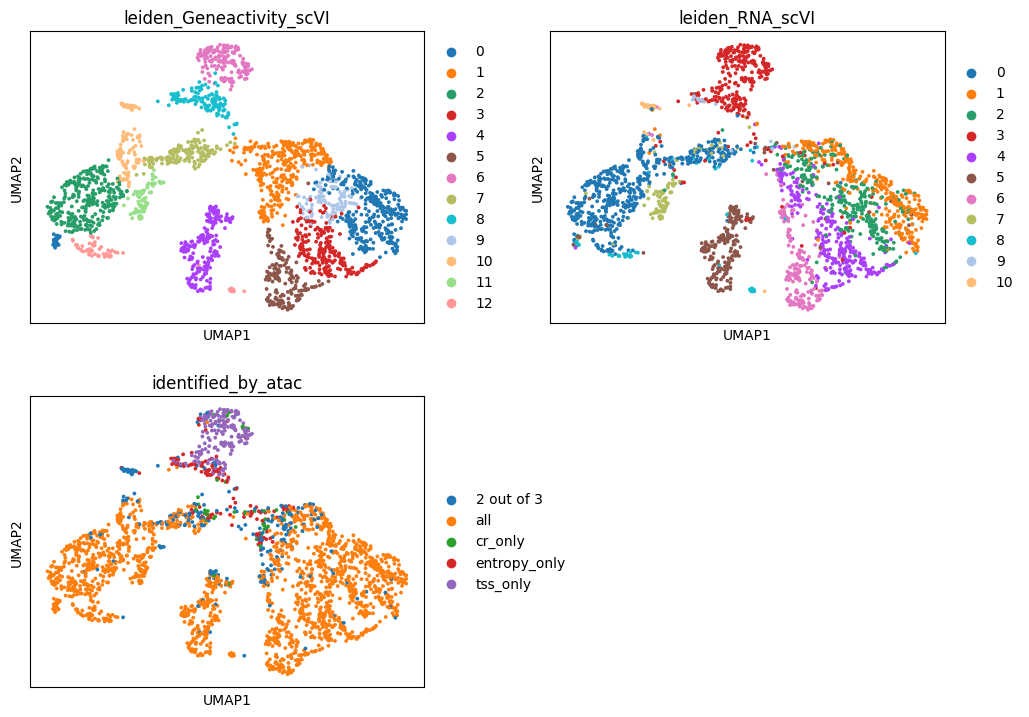

In [121]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(gene_activity_h5, color=['leiden_Geneactivity_scVI',  'leiden_RNA_scVI', 'identified_by_atac'], wspace=0.2, size=30, ncols=2)

In [118]:
gene_activity_h5.obs.groupby(['leiden_Geneactivity_scVI', 'identified_by_atac']).size().unstack()

/tmp/ipykernel_2538860/2176167152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_activity_h5.obs.groupby(['leiden_Geneactivity_scVI', 'identified_by_atac']).size().unstack()


identified_by_atac,2 out of 3,all,cr_only,entropy_only,tss_only
leiden_Geneactivity_scVI,,,,,
0,7,345,0,0,0
1,94,177,17,43,0
2,7,294,0,0,0
3,4,232,0,0,0
4,24,181,3,0,0
5,2,176,0,0,0
6,6,1,6,7,138
7,45,70,11,13,0
8,13,2,2,56,51


In [116]:
# calculate total RNA-like QC metrics
gene_activity_h5.obs['total_gene_activity'] = gene_activity_h5.X.sum(axis=1)
gene_activity_h5.obs['total_gene_activity_log'] = np.log1p(gene_activity_h5.obs['total_gene_activity'])
gene_activity_h5.obs['n_genes_by_activity'] = (gene_activity_h5.X > 0).sum(axis=1)
gene_activity_h5.obs['n_genes_by_activity_log'] = np.log1p(gene_activity_h5.obs['n_genes_by_activity'])

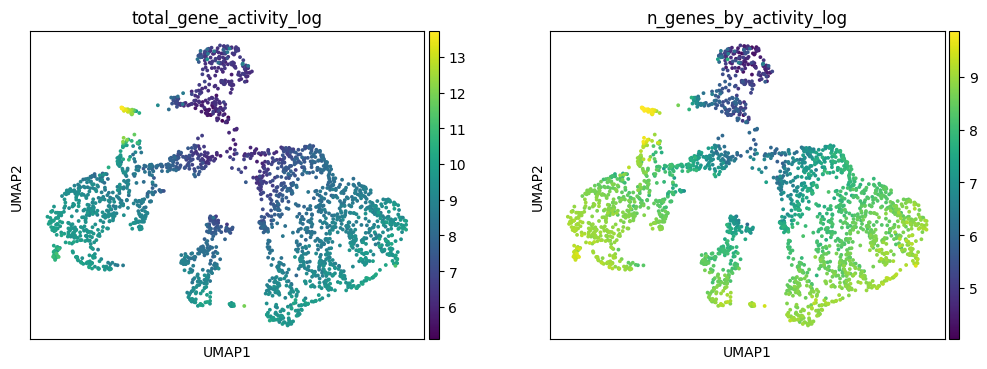

In [117]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(gene_activity_h5, color=['total_gene_activity_log',  'n_genes_by_activity_log'], wspace=0.2, size=30, ncols=3)

# Check counts in peak categories (newly, dropped, overlapped) per barcode 

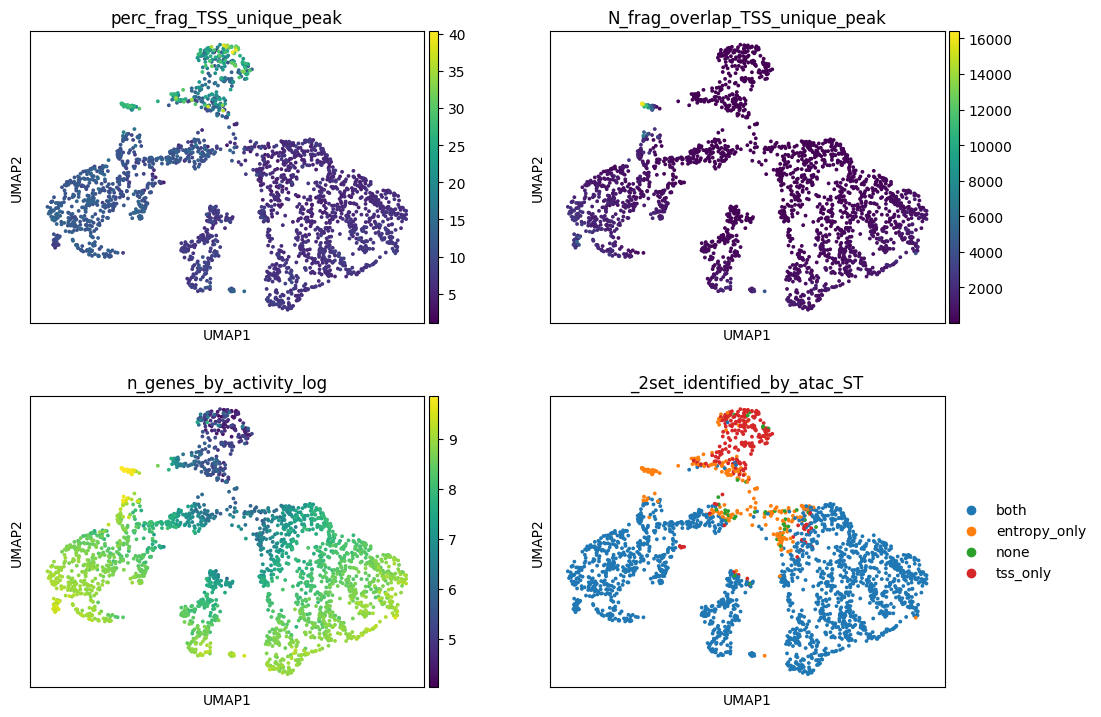

In [162]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(gene_activity_h5, color=['perc_frag_TSS_unique_peak',  
                                        'N_frag_overlap_TSS_unique_peak', 
                                        'n_genes_by_activity_log', 
                                        '_2set_identified_by_atac_ST'], wspace=0.2, size=30, ncols=2)

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [8.070581, 17.661345]
median 	 [nan, 16.763006]


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


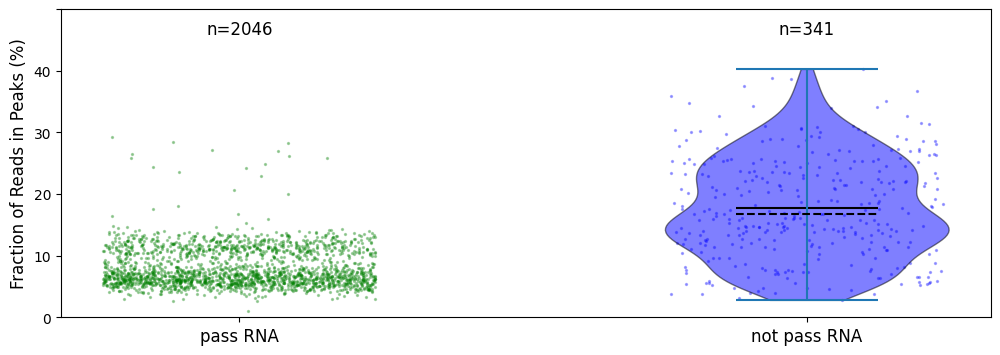

In [199]:
fig, ax = plt.subplots(figsize=(12, 4))

x_positions = range(2)
width = 0.5

colors_map = ['green', 'blue']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['rna_pass_CR'] == True, 'perc_frag_TSS_unique_peak'], 
                total_frag_per_bc.loc[total_frag_per_bc['rna_pass_CR'] == False, 'perc_frag_TSS_unique_peak']
       ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['pass RNA', 'not pass RNA'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 50)
ax.set_yticks(range(0, 51, 10))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

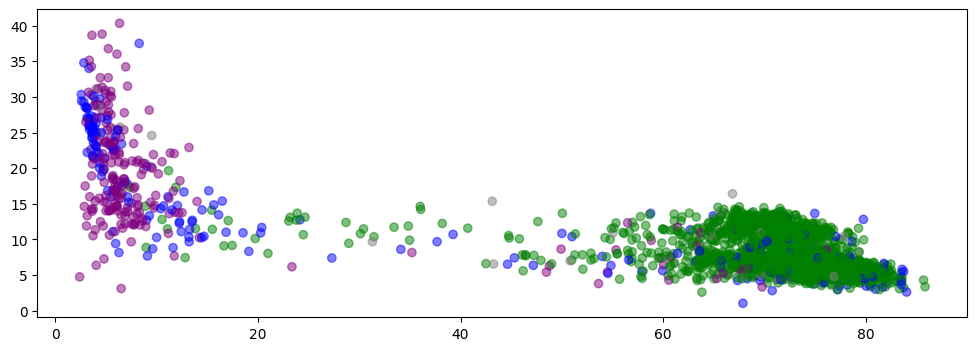

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(total_frag_per_bc['CRpeak_FRIP'], total_frag_per_bc['perc_frag_TSS_unique_peak'], 
        c = total_frag_per_bc['_2set_identified_by_atac_ST'].map(
                {'both': 'green', 'entropy_only': 'blue', 'tss_only': 'purple', 'none': 'grey'}
                ),
        alpha=0.5)

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [8.5437155, 17.788317, 19.699564, 17.470634]
median 	 [7.400408, 15.978724, 18.518518, 24.580153]


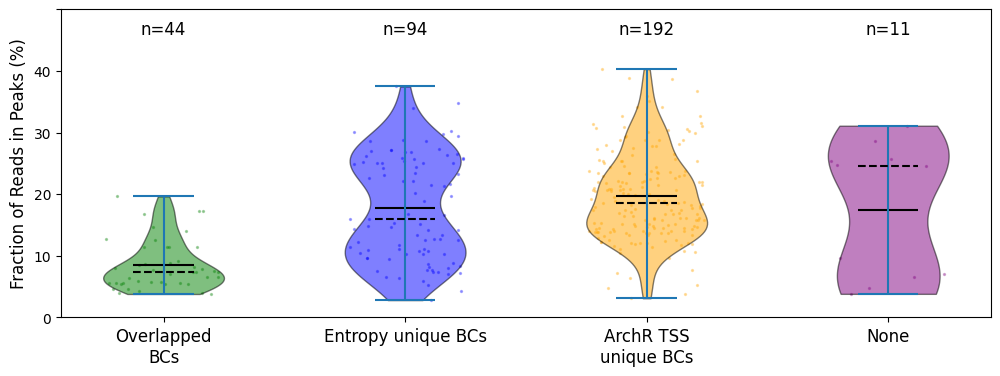

In [200]:
no_pass_rna_df = total_frag_per_bc.loc[total_frag_per_bc['rna_pass_CR'] == False].copy()

fig, ax = plt.subplots(figsize=(12, 4))

x_positions = range(4)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'purple']
frip_values = [ no_pass_rna_df.loc[no_pass_rna_df['_2set_identified_by_atac_ST'] == cat, 'perc_frag_TSS_unique_peak'].fillna(0) for cat in 
               ['both', 'entropy_only', 'tss_only', 'none'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy unique BCs',  'ArchR TSS\nunique BCs', 'None'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 50)
ax.set_yticks(range(0, 51, 10))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

----- 	 both 	 entropy_only 	 cr_only 	 none
mean 	 [7.943456, 13.3430395, 11.161937, 19.854229, 10.121602]
median 	 [7.049158, 10.447762, 9.6875, 18.518518, 7.597324]


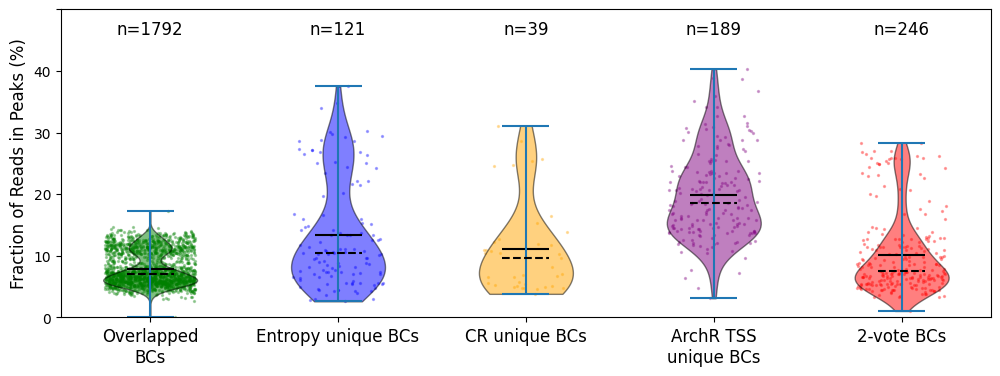

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

x_positions = range(5)
width = 0.5

colors_map = ['green', 'blue', 'orange', 'purple', 'red']
frip_values = [ total_frag_per_bc.loc[total_frag_per_bc['identified_by_atac'] == cat, 'perc_frag_TSS_unique_peak'].fillna(0) for cat in 
               ['all', 'entropy_only', 'cr_only', 'tss_only', '2 out of 3'] ]
total_counts = [a.shape[0] for a in frip_values]

mean_frip_values = [np.mean(a) for a in frip_values]
median_frip_values = [np.median(a) for a in frip_values]
# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.24, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size
    
for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_map[i])


v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=width, vert=True, 
              showmedians=True, showmeans=True)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_map[i])
    body.set_edgecolor('black')
    body.set_alpha(0.5)
v1['cmedians'].set_color('black') 
v1['cmedians'].set_linestyles('--')
v1['cmeans'].set_color('black') 

ax.set_xticks(x_positions)
ax.set_xticklabels(['Overlapped\nBCs', 'Entropy unique BCs', 'CR unique BCs', 'ArchR TSS\nunique BCs', '2-vote BCs'], 
                   rotation=0, ha='center', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
ax.set_ylim(0, 50)
ax.set_yticks(range(0, 51, 10))
y_labels = ax.get_yticklabels()
y_labels[-1].set_visible(False)

for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1]*0.92, f'n={count}', ha='center', fontsize=12)

# ax.set_title('FRIP in CR Peaks', fontsize=14)

print('----- \t both \t entropy_only \t cr_only \t none')
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')